# 07 — Evaluation: False Negative Analysis

Detailed false negative analysis — cases where the model missed malignant tumors. ROC/PR evaluation on an extended dataset.

> **Note:** Data and model paths use relative references. Ensure the `data/` and `models/` directories are set up according to `README.md`.

In [ ]:
import os, csv, itertools, warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    classification_report
)
import matplotlib.pyplot as plt


In [ ]:
OUTPUT_BENIGN_DIR = "../data/train/benign"
OUTPUT_MALIGNANT_DIR = "../data/train/malignant"

K_SHOT       = 30 #
N_WAY        = 2 
NUM_EPISODES = 500
LEARNING_RATE= 5e-5 #
TEST_SIZE    = 0.3 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision("high")  # Ampere (RTX 30xx)
except Exception:
    pass


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomCrop(224, padding=8), #
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
class LiverTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


def create_episode(dataset, k_shot, n_way):
    benign_indices    = [i for i in range(len(dataset.labels)) if dataset.labels[i] == 0]
    malignant_indices = [i for i in range(len(dataset.labels)) if dataset.labels[i] == 1]

    if len(benign_indices) < k_shot or len(malignant_indices) < k_shot:
        raise ValueError(f"Không đủ ảnh. Cần ít nhất {k_shot} ảnh mỗi lớp.")

    support_benign    = np.random.choice(benign_indices,    k_shot, replace=False)
    support_malignant = np.random.choice(malignant_indices, k_shot, replace=False)
    support_indices   = list(support_benign) + list(support_malignant)

    pool_indices = [i for i in range(len(dataset.labels)) if i not in support_indices]
    required_query = k_shot * n_way
    if len(pool_indices) < required_query:
        query_indices = np.random.choice(range(len(dataset.labels)), required_query, replace=True)
    else:
        query_indices = np.random.choice(pool_indices, required_query, replace=False)

    support_images = torch.stack([dataset[i][0] for i in support_indices])
    support_labels = torch.tensor([dataset[i][1] for i in support_indices])
    query_images   = torch.stack([dataset[i][0] for i in query_indices])
    query_labels   = torch.tensor([dataset[i][1] for i in query_indices])
    return support_images, support_labels, query_images, query_labels


In [ ]:
class ProtoNet(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.backbone.fc = nn.Identity()

    def forward(self, support_images, support_labels, query_images, n_way=2):
        support_features = self.backbone(support_images)  # [S, D]
        query_features   = self.backbone(query_images)    # [Q, D]

        prototypes = []
        for c in range(n_way):
            mask = (support_labels == c)
            prototype = support_features[mask].mean(dim=0)
            prototypes.append(prototype)
        prototypes = torch.stack(prototypes)              # [C, D]

        dists = torch.cdist(query_features, prototypes)   # [Q, C]
        return -dists ##


In [ ]:
def list_images(folder):
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    return [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(exts)]

benign_images    = list_images(OUTPUT_BENIGN_DIR)
malignant_images = list_images(OUTPUT_MALIGNANT_DIR)
all_images  = benign_images + malignant_images
all_labels  = [0]*len(benign_images) + [1]*len(malignant_images)

if len(all_images) == 0:
    raise ValueError("Không tìm thấy ảnh trong benign hoặc malignant.")
if len(benign_images) < K_SHOT or len(malignant_images) < K_SHOT:
    raise ValueError(f"Không đủ ảnh. Cần ít nhất {K_SHOT} ảnh mỗi lớp.")

train_idx, test_idx = train_test_split(
    range(len(all_images)), test_size=TEST_SIZE, stratify=all_labels, random_state=42
) #

train_dataset = LiverTumorDataset([all_images[i] for i in train_idx],
                                  [all_labels[i] for i in train_idx], transform)
test_dataset  = LiverTumorDataset([all_images[i] for i in test_idx],
                                  [all_labels[i] for i in test_idx],  val_transform)

print(f"Số ảnh trong train_dataset: {len(train_dataset)}")
print(f"Số ảnh trong test_dataset:  {len(test_dataset)}")


Số ảnh trong train_dataset: 443
Số ảnh trong test_dataset:  191


In [ ]:
model = ProtoNet(models.resnet34(weights=models.ResNet34_Weights.DEFAULT)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
scaler = torch.amp.GradScaler('cuda')

In [ ]:
best_val_f1 = -1.0
best_episode = 0
best_model_path = 'best_protonet_liver_tumor_resnet34.pth'
best_val_acc = best_val_precision = best_val_recall = 0.0
best_val_cm  = np.zeros((N_WAY, N_WAY), dtype=int)

metrics_log = []
best_val_auc = None
best_val_ap  = None
best_val_y_true  = None
best_val_y_score = None

model.train()
train_acc_hist, train_loss_hist, val_acc_hist = [], [], []
train_f1_hist,  val_f1_hist  = [], []

for episode in range(NUM_EPISODES):
    support_images, support_labels, query_images, query_labels = create_episode(train_dataset, K_SHOT, N_WAY)
    support_images, support_labels = support_images.to(DEVICE), support_labels.to(DEVICE)
    query_images,   query_labels   = query_images.to(DEVICE),   query_labels.to(DEVICE)

    optimizer.zero_grad(set_to_none=True)
    with torch.amp.autocast('cuda'):
        outputs = model(support_images, support_labels, query_images, n_way=N_WAY)
        loss    = criterion(outputs, query_labels)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    if query_labels.numel() > 0:
        with torch.no_grad():
            _, predicted = torch.max(outputs, 1)
            y_true = query_labels.detach().cpu().numpy()
            y_pred = predicted.detach().cpu().numpy()
            acc = accuracy_score(y_true, y_pred)
            f1  = f1_score(y_true, y_pred, average='weighted')
        cm  = confusion_matrix(y_true, y_pred)
        train_acc_hist.append(acc)
        train_loss_hist.append(float(loss.item()))
        train_f1_hist.append(f1)
    else:
        train_acc_hist.append(0.0)
        train_loss_hist.append(float(loss.item()))
        train_f1_hist.append(0.0)


    if (episode + 1) % 10 == 0:
        print(f"Episode {episode+1}/{NUM_EPISODES}, Loss: {loss.item():.4f}, "
              f"Train Acc: {acc:.4f}, F1: {f1:.4f}")

        model.eval()
        test_acc = test_f1 = test_precision = test_recall = 0.0
        test_cm = np.zeros((N_WAY, N_WAY), dtype=int)
        valid_eps = 0

        all_val_y_true_list  = []
        all_val_y_score_list = []

        with torch.no_grad():
            for _ in range(10):
                sup_img, sup_lab, qry_img, qry_lab = create_episode(test_dataset, K_SHOT, N_WAY)
                sup_img, sup_lab = sup_img.to(DEVICE), sup_lab.to(DEVICE)
                qry_img, qry_lab = qry_img.to(DEVICE), qry_lab.to(DEVICE)

                with torch.amp.autocast('cuda'):
                    out = model(sup_img, sup_lab, qry_img, n_way=N_WAY)

                if qry_lab.numel() > 0:
                    probs = torch.softmax(out, dim=1)             # [B, 2]
                    p_malignant = probs[:, 1].detach().cpu().numpy()
                    _, pred = torch.max(out, 1)
                    y_t = qry_lab.detach().cpu().numpy()
                    y_p = pred.detach().cpu().numpy()

                    all_val_y_true_list.append(y_t)
                    all_val_y_score_list.append(p_malignant)

                    test_acc      += accuracy_score(y_t, y_p)
                    test_f1       += f1_score(y_t, y_p, average='weighted')
                    test_precision+= precision_score(y_t, y_p, average='weighted')
                    test_recall   += recall_score(y_t, y_p, average='weighted')
                    test_cm       += confusion_matrix(y_t, y_p)
                    valid_eps     += 1

        if valid_eps > 0:
            val_acc = test_acc / valid_eps
            val_f1  = test_f1  / valid_eps
            val_precision = test_precision / valid_eps
            val_recall    = test_recall    / valid_eps
            val_cm = (test_cm // valid_eps).astype(int)
        else:
            val_acc = val_f1 = val_precision = val_recall = 0.0
            val_cm  = np.zeros((N_WAY, N_WAY), dtype=int)

        val_acc_hist.append(val_acc)
        val_f1_hist.append(val_f1)

        if len(all_val_y_true_list) > 0:
            all_val_y_true  = np.concatenate(all_val_y_true_list)
            all_val_y_score = np.concatenate(all_val_y_score_list)
            fpr, tpr, _ = roc_curve(all_val_y_true, all_val_y_score)
            val_auc = auc(fpr, tpr)
            pr_prec, pr_rec, _ = precision_recall_curve(all_val_y_true, all_val_y_score)
            val_ap  = average_precision_score(all_val_y_true, all_val_y_score)
        else:
            val_auc = np.nan
            val_ap  = np.nan

        print(f"Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}, AUC: {val_auc:.4f}, AP: {val_ap:.4f}")
        print(f"Val Confusion Matrix:\n{val_cm}")

        metrics_log.append({
            "episode": episode + 1,
            "val_acc": val_acc,
            "val_f1":  val_f1,
            "val_precision": val_precision,
            "val_recall":    val_recall,
            "val_auc":       val_auc,
            "val_ap":        val_ap
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_episode = episode + 1
            best_val_acc = val_acc
            best_val_precision = val_precision
            best_val_recall    = val_recall
            best_val_cm        = val_cm
            best_val_auc       = val_auc
            best_val_ap        = val_ap
            best_val_y_true    = all_val_y_true.copy()
            best_val_y_score   = all_val_y_score.copy()
            torch.save(model.state_dict(), best_model_path)
            print(f"=== Lưu mô hình tốt nhất tại episode {best_episode} ===")

        scheduler.step(val_f1)
        model.train()

torch.save(model.state_dict(), 'improved_protonet_liver_tumor_resnet34.pth')

print("\n=== Kết quả tốt nhất ===")
print(f"Episode: {best_episode}")
print(f"Val Acc: {best_val_acc:.4f}, Val F1: {best_val_f1:.4f}, Val Precision: {best_val_precision:.4f}, Val Recall: {best_val_recall:.4f}")
print(f"Val Confusion Matrix:\n{best_val_cm}")
if best_val_auc is not None and best_val_ap is not None:
    print(f"AUC: {best_val_auc:.4f}, AP: {best_val_ap:.4f}")


Episode 10/500, Loss: 0.5459, Train Acc: 0.6833, F1: 0.6834
Val Acc: 0.7383, Val F1: 0.7367, Val Precision: 0.7478, Val Recall: 0.7383, AUC: 0.8207, AP: 0.8083
Val Confusion Matrix:
[[23  6]
 [ 9 20]]
=== Lưu mô hình tốt nhất tại episode 10 ===
Episode 20/500, Loss: 0.4164, Train Acc: 0.8167, F1: 0.8185
Val Acc: 0.8050, Val F1: 0.8017, Val Precision: 0.8253, Val Recall: 0.8050, AUC: 0.8811, AP: 0.8928
Val Confusion Matrix:
[[27  2]
 [ 9 21]]
=== Lưu mô hình tốt nhất tại episode 20 ===
Episode 30/500, Loss: 0.1822, Train Acc: 0.9333, F1: 0.9330
Val Acc: 0.8683, Val F1: 0.8668, Val Precision: 0.8838, Val Recall: 0.8683, AUC: 0.9303, AP: 0.9424
Val Confusion Matrix:
[[27  1]
 [ 6 24]]
=== Lưu mô hình tốt nhất tại episode 30 ===
Episode 40/500, Loss: 0.2125, Train Acc: 0.9167, F1: 0.9166
Val Acc: 0.8633, Val F1: 0.8629, Val Precision: 0.8753, Val Recall: 0.8633, AUC: 0.9272, AP: 0.9418
Val Confusion Matrix:
[[25  2]
 [ 5 25]]
Episode 50/500, Loss: 0.1655, Train Acc: 0.9667, F1: 0.9666
Val 

In [12]:
torch.save(model.state_dict(), 'improved_protonet_liver_tumor_resnet34.pth')

print("\n=== Kết quả tốt nhất ===")
print(f"Episode: {best_episode}")
print(f"Val Acc: {best_val_acc:.4f}, Val F1: {best_val_f1:.4f}, Val Precision: {best_val_precision:.4f}, Val Recall: {best_val_recall:.4f}")
print(f"Val Confusion Matrix:\n{best_val_cm}")
if best_val_auc is not None and best_val_ap is not None:
    print(f"AUC: {best_val_auc:.4f}, AP: {best_val_ap:.4f}")



=== Kết quả tốt nhất ===
Episode: 450
Val Acc: 0.9467, Val F1: 0.9467, Val Precision: 0.9498, Val Recall: 0.9467
Val Confusion Matrix:
[[28  0]
 [ 2 28]]
AUC: 0.9830, AP: 0.9850


In [13]:
def plot_training_metrics(train_acc_hist, train_loss_hist, val_acc_hist, train_f1_hist, val_f1_hist,
                          num_episodes, best_episode, best_val_f1):
    epochs = range(1, num_episodes + 1)
    val_epochs = range(10, num_episodes + 1, 10)

    plt.figure(figsize=(12, 12))

    # Train Acc
    plt.subplot(4, 1, 1)
    plt.plot(epochs, train_acc_hist, label='Train Accuracy')
    plt.title('Train Accuracy Over Episodes'); plt.xlabel('Episode'); plt.ylabel('Accuracy')
    plt.grid(True); plt.legend(); plt.ylim(0, 1)

    # Train Loss
    plt.subplot(4, 1, 2)
    plt.plot(epochs, train_loss_hist, label='Train Loss')
    plt.title('Train Loss Over Episodes'); plt.xlabel('Episode'); plt.ylabel('Loss')
    plt.grid(True); plt.legend()

    # Val Acc
    plt.subplot(4, 1, 3)
    plt.plot(val_epochs, val_acc_hist, label='Val Accuracy')
    plt.axvline(x=best_episode, linestyle='--', label=f'Best Val F1 @ Ep {best_episode}')
    plt.title('Validation Accuracy Over Episodes'); plt.xlabel('Episode'); plt.ylabel('Accuracy')
    plt.grid(True); plt.legend(); plt.ylim(0, 1)

    # F1
    plt.subplot(4, 1, 4)
    plt.plot(epochs, train_f1_hist, label='Train F1')
    plt.plot(val_epochs, val_f1_hist, label='Val F1')
    plt.axvline(x=best_episode, linestyle='--', label=f'Best Val F1: {best_val_f1:.4f}')
    plt.title('F1-score Over Episodes'); plt.xlabel('Episode'); plt.ylabel('F1-score')
    plt.grid(True); plt.legend(); plt.ylim(0, 1)

    plt.tight_layout()
    plt.savefig('training_metrics.png', dpi=200, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', fname=None):
    plt.figure(figsize=(4.8, 4.2))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title); plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes); plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()

def plot_roc_curve(y_true, y_score, label='Best', title='ROC Curve', fname=None):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5.5, 5))
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], linestyle='--', lw=1, label='Random')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(title); plt.legend(loc='lower right'); plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()

def plot_pr_curve(y_true, y_score, label='Best', title='Precision-Recall Curve', fname=None):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    plt.figure(figsize=(5.5, 5))
    plt.plot(recall, precision, lw=2, label=f'{label} (AP = {ap:.3f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(title); plt.legend(loc='lower left'); plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()

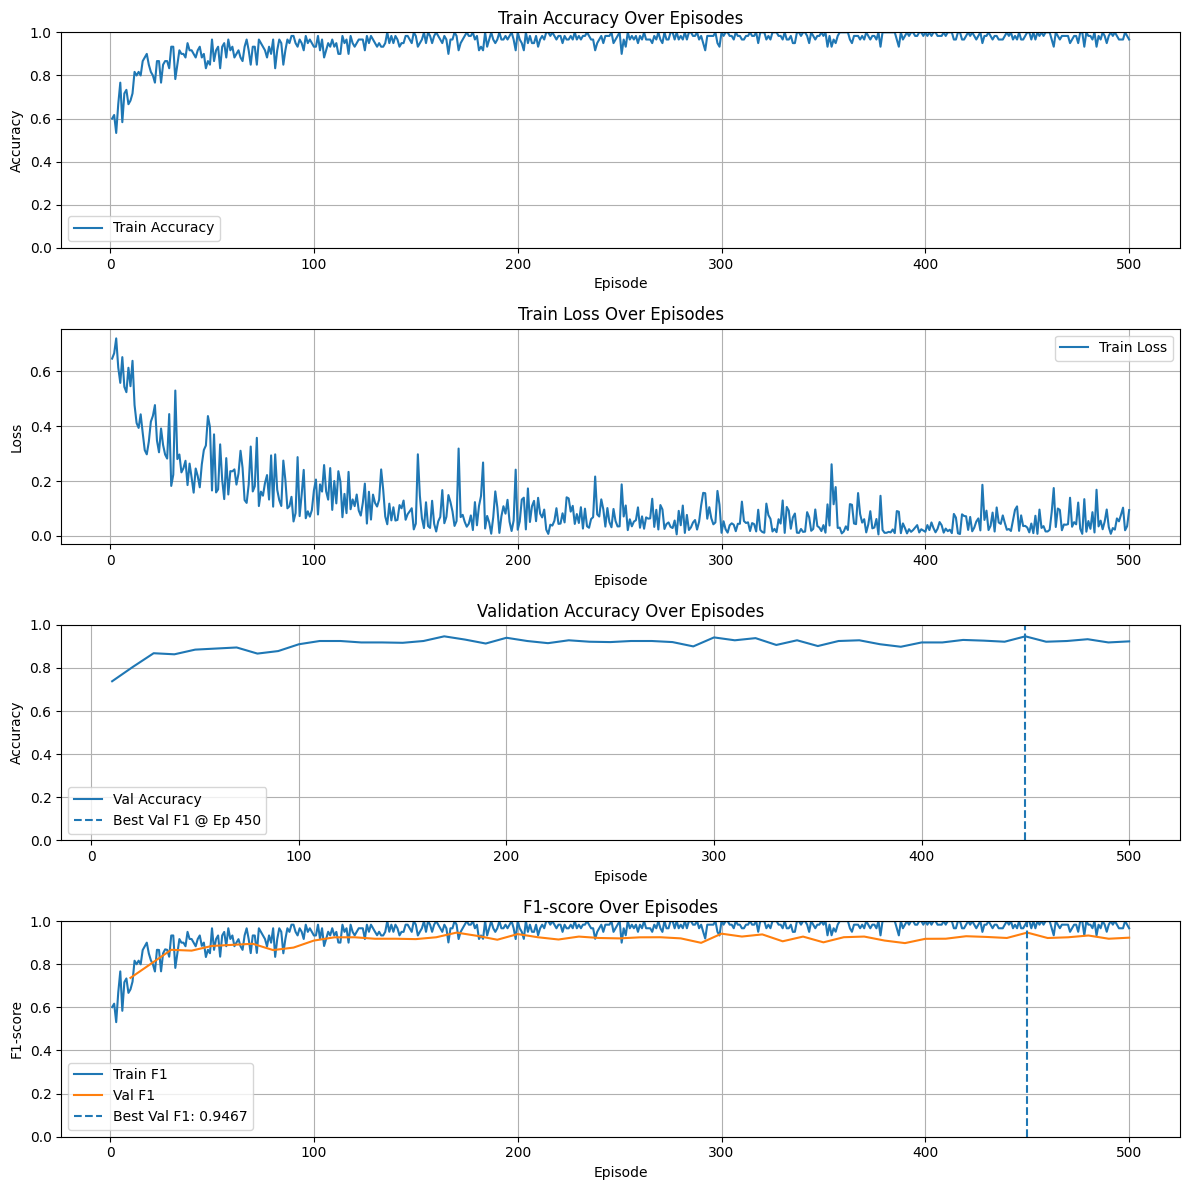


=== Classification Report (Best, threshold=0.5) ===
              precision    recall  f1-score   support

      Benign     0.9164    0.9794    0.9468       291
   Malignant     0.9792    0.9159    0.9465       309

    accuracy                         0.9467       600
   macro avg     0.9478    0.9476    0.9467       600
weighted avg     0.9488    0.9467    0.9467       600



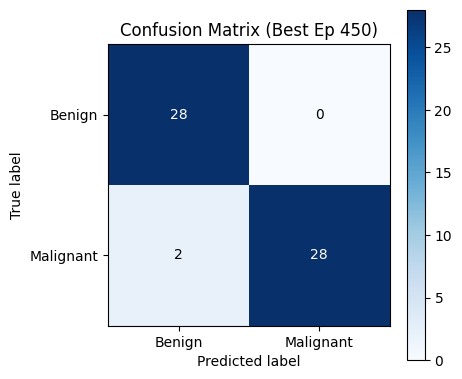

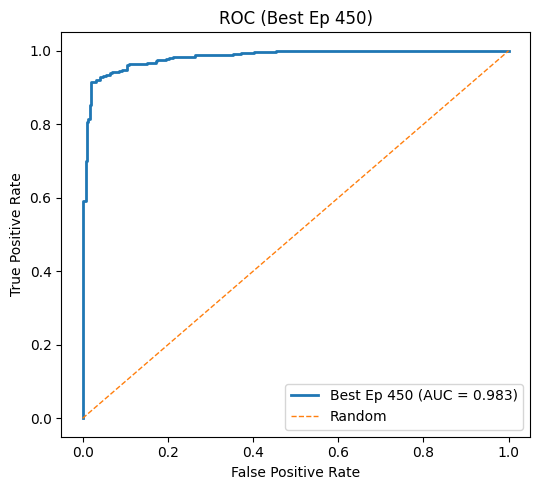

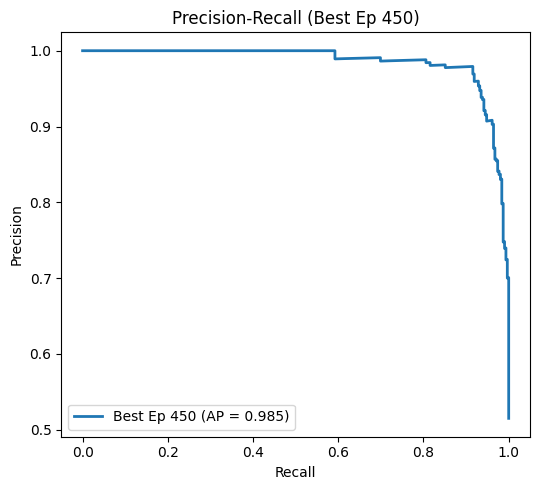

In [14]:
plot_training_metrics(train_acc_hist, train_loss_hist, val_acc_hist,
                      train_f1_hist, val_f1_hist,
                      NUM_EPISODES, best_episode, best_val_f1)

if best_val_y_true is not None and best_val_y_score is not None:
    class_names = ['Benign', 'Malignant']
    y_pred_best = (best_val_y_score >= 0.5).astype(int)
    print("\n=== Classification Report (Best, threshold=0.5) ===")
    print(classification_report(best_val_y_true, y_pred_best, target_names=class_names, digits=4))

    plot_confusion_matrix(best_val_cm, classes=class_names,
                          title=f'Confusion Matrix (Best Ep {best_episode})',
                          fname=f'cm_best_ep{best_episode}.png')

    plot_roc_curve(best_val_y_true, best_val_y_score,
                   label=f'Best Ep {best_episode}',
                   title=f'ROC (Best Ep {best_episode})',
                   fname=f'roc_best_ep{best_episode}.png')

    plot_pr_curve(best_val_y_true, best_val_y_score,
                  label=f'Best Ep {best_episode}',
                  title=f'Precision-Recall (Best Ep {best_episode})',
                  fname=f'pr_best_ep{best_episode}.png')
else:
    print("[WARN] Chưa có y_true/y_score để vẽ ROC/PR cho best episode (kiểm tra đoạn gom trong validation).")


In [15]:
csv_path = 'metrics_log.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['episode','val_acc','val_f1','val_precision','val_recall','val_auc','val_ap'])
    writer.writeheader()
    for row in metrics_log:
        writer.writerow(row)
print(f"[INFO] Đã ghi log metrics tại {csv_path}")


[INFO] Đã ghi log metrics tại metrics_log.csv
